In [60]:
import pandas as pd
import yfinance as yf
import matplotlib.pyplot as plt

In [71]:
def get_single_stock_data(ticker, interval="1d", period="max"):
    df = yf.download(tickers=ticker, interval=interval, period=period, group_by="ticker", auto_adjust=True)
    df.columns = df.columns.droplevel(0)
    df.columns.name = None
    df.columns = df.columns.str.lower()
    # convert index to datetime and rename it to 'date'
    df.index = pd.to_datetime(df.index)
    df.index.name = 'date'
    return df


In [74]:
df_pep = get_single_stock_data("PEP")
df_ko = get_single_stock_data("KO")

[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed


In [75]:
df_pep

,open,high,low,close,volume
date,,,,,
1972-06-01,0.366389,0.370674,0.366389,0.370674,318600
1972-06-02,0.370674,0.374424,0.369603,0.369603,140400
1972-06-05,0.370677,0.371215,0.358322,0.365305,469800
1972-06-06,0.362082,0.362082,0.361008,0.362082,140400
1972-06-07,0.362082,0.362619,0.358859,0.359933,178200
...,...,...,...,...,...
2026-08-31,141.039993,141.039993,139.330002,140.339996,6555600
2026-09-01,141.190002,141.429993,139.369995,139.789993,5529500
2026-09-02,140.270004,141.710007,139.300003,140.520004,7054500


In [76]:
df_ko

,open,high,low,close,volume
date,,,,,
1962-01-02,0.044457,0.045668,0.044457,0.044457,806400
1962-01-03,0.043797,0.043797,0.042807,0.043467,1574400
1962-01-04,0.043577,0.044127,0.043577,0.043797,844800
1962-01-05,0.043797,0.044347,0.042697,0.042807,1420800
1962-01-08,0.042477,0.042477,0.041541,0.042367,2035200
...,...,...,...,...,...
2026-08-31,89.510002,89.529999,88.599998,88.669998,23764800
2026-09-01,89.589996,89.779999,87.809998,88.000000,14824100
2026-09-02,87.900002,88.949997,87.730003,88.239998,18492800


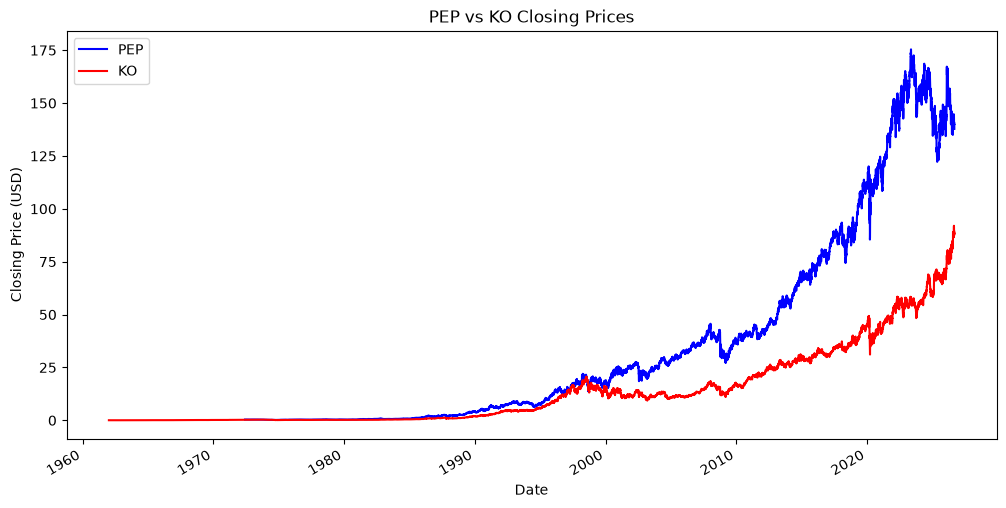

In [81]:
plt.figure(figsize=(12, 6))

df_pep['close'].plot(label='PEP', color='blue')
df_ko['close'].plot(label='KO', color='red')

plt.legend()
plt.xlabel('Date')
plt.ylabel('Closing Price (USD)')
plt.title('PEP vs KO Closing Prices')

plt.show()

In [85]:
df_merged = df_pep.merge(df_ko, on='date', how='inner', suffixes=("_pep", "_ko"))
df_merged

,open_pep,high_pep,low_pep,close_pep,volume_pep,open_ko,high_ko,low_ko,close_ko,volume_ko
date,,,,,,,,,,
1972-06-01,0.366389,0.370674,0.366389,0.370674,318600,0.288607,0.289421,0.286706,0.287249,748800
1972-06-02,0.370674,0.374424,0.369603,0.369603,140400,0.286706,0.286706,0.285620,0.286163,393600
1972-06-05,0.370677,0.371215,0.358322,0.365305,469800,0.286163,0.286706,0.285077,0.285620,662400
1972-06-06,0.362082,0.362082,0.361008,0.362082,140400,0.284534,0.284534,0.282634,0.283177,768000
1972-06-07,0.362082,0.362619,0.358859,0.359933,178200,0.281820,0.281820,0.279647,0.281820,1420800
...,...,...,...,...,...,...,...,...,...,...
2026-08-31,141.039993,141.039993,139.330002,140.339996,6555600,89.510002,89.529999,88.599998,88.669998,23764800
2026-09-01,141.190002,141.429993,139.369995,139.789993,5529500,89.589996,89.779999,87.809998,88.000000,14824100
2026-09-02,140.270004,141.710007,139.300003,140.520004,7054500,87.900002,88.949997,87.730003,88.239998,18492800


In [92]:
df_merged[['close_pep', 'close_ko']].to_csv('../data/pep_ko_daily_close_data.csv', index=True)